# NBA Championship Probability Model
**Data source:** `nba_api` (official NBA stats API)  
**Model:** LASSO-regularized logistic regression  
**Training data:** 2000-2025 seasons (25 years)  
**Prediction target:** 2025-26 season  

> **Setup:** `pip install nba_api pandas numpy scikit-learn matplotlib seaborn`


## 1. Imports & Configuration

In [3]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nba_api.stats.endpoints import (
    leaguedashteamstats,
    leaguestandings,
)
from nba_api.stats.static import teams as nba_teams_static

from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    log_loss, accuracy_score, roc_auc_score, roc_curve
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
%matplotlib inline

### Season configuration ###
# Training seasons: 2000-2025 (have known champions)
# Prediction season: 2026 (current - no champion yet(as of May 2026))
TRAIN_SEASONS = list(range(2000, 2026))   # 2000 = 1999-00 season
PREDICT_SEASON = 2026                      # 2025-26 season

# Champions keyed by season end-year
CHAMPIONS = {
    2000: "Los Angeles Lakers",
    2001: "Los Angeles Lakers",
    2002: "Los Angeles Lakers",
    2003: "San Antonio Spurs",
    2004: "Detroit Pistons",
    2005: "San Antonio Spurs",
    2006: "Miami Heat",
    2007: "San Antonio Spurs",
    2008: "Boston Celtics",
    2009: "Los Angeles Lakers",
    2010: "Los Angeles Lakers",
    2011: "Dallas Mavericks",
    2012: "Miami Heat",
    2013: "Miami Heat",
    2014: "San Antonio Spurs",
    2015: "Golden State Warriors",
    2016: "Cleveland Cavaliers",
    2017: "Golden State Warriors",
    2018: "Golden State Warriors",
    2019: "Toronto Raptors",
    2020: "Los Angeles Lakers",
    2021: "Milwaukee Bucks",
    2022: "Golden State Warriors",
    2023: "Denver Nuggets",
    2024: "Boston Celtics",
    2025: "Oklahoma City Thunder",
    # 2026: no champion yet - prediction target
}

def season_str(year: int) -> str:
    """Convert 2024 -> '2023-24' format expected by nba_api."""
    return f"{year-1}-{str(year)[-2:]}"

print("Imports OK")
print(f"Training seasons : {season_str(TRAIN_SEASONS[0])} -> {season_str(TRAIN_SEASONS[-1])}  ({len(TRAIN_SEASONS)} seasons)")
print(f"Prediction season: {season_str(PREDICT_SEASON)}")


Imports OK
Training seasons : 1999-00 → 2024-25  (26 seasons)
Prediction season: 2025-26


## 2. Data Collection

We pull **two** tables per season from `nba_api` and merge them:

| Endpoint | What we get |
|---|---|
| `LeagueDashTeamStats` (Base) | W, L, FG%, 3P%, FT%, rebounds, assists, turnovers, +/- |
| `LeagueDashTeamStats` (Advanced) | ORtg, DRtg, NetRtg, Pace, TS%, PIE, AST%, REB%, TOV% |
| `LeagueStandings` | Win%, playoff seeding, point differential |

> **Note:** The API has rate limits. We sleep 0.7s between calls.  
> Collecting 26 seasons takes approximately **3–4 minutes**.


In [4]:
def fetch_season(year: int, is_prediction: bool = False) -> pd.DataFrame:
    """
    Fetch and merge base + advanced team stats for one NBA season.

    Args:
        year           : season end year (e.g. 2026 for 2025-26)
        is_prediction  : if True, champion flag is set to 0 for all teams
    Returns:
        DataFrame with one row per team
    """
    ssn = season_str(year)
    print(f"  {ssn} ... ", end="", flush=True)

    # Base stats
    time.sleep(0.7)
    base = leaguedashteamstats.LeagueDashTeamStats(
        season=ssn,
        measure_type_detailed_defense="Base",
        per_mode_detailed="PerGame",
        season_type_all_star="Regular Season",
    ).get_data_frames()[0]

    # Advanced stats
    time.sleep(0.7)
    adv = leaguedashteamstats.LeagueDashTeamStats(
        season=ssn,
        measure_type_detailed_defense="Advanced",
        per_mode_detailed="PerGame",
        season_type_all_star="Regular Season",
    ).get_data_frames()[0]

    # Standings
    time.sleep(0.7)
    try:
        standings = leaguestandings.LeagueStandings(
            season=ssn,
            season_type="Regular Season",
        ).get_data_frames()[0]
        std_keep = ["TeamID", "TeamName", "PlayoffSeeding", "WinPCT",
                    "PointsPG", "OppPointsPG", "DiffPointsPG"]
        standings = standings[[c for c in std_keep if c in standings.columns]]
        standings = standings.rename(columns={"TeamID": "TEAM_ID", "TeamName": "TEAM_NAME"})
    except Exception:
        standings = None

    # Select relevant columns
    base_keep = ["TEAM_ID", "TEAM_NAME", "GP", "W", "L",
                 "FG_PCT", "FG3_PCT", "FG3A", "FT_PCT", "FTA",
                 "OREB", "DREB", "REB", "AST", "TOV", "STL", "BLK",
                 "PLUS_MINUS"]
    adv_keep  = ["TEAM_ID", "OFF_RATING", "DEF_RATING", "NET_RATING",
                 "AST_PCT", "AST_TO", "OREB_PCT", "DREB_PCT", "REB_PCT",
                 "TM_TOV_PCT", "EFG_PCT", "TS_PCT", "PACE", "PIE"]

    base = base[[c for c in base_keep if c in base.columns]]
    adv  = adv[[c  for c in adv_keep  if c in adv.columns]]

    df = base.merge(adv, on="TEAM_ID", how="left")
    if standings is not None:
        df = df.merge(standings, on="TEAM_ID", how="left", suffixes=("", "_std"))

    # Champion flag
    if is_prediction:
        df["champion"] = 0
    else:
        champion = CHAMPIONS.get(year, "")
        df["champion"] = df["TEAM_NAME"].str.contains(
            champion.split()[-1] if champion else "XXXXXXX",
            case=False, na=False
        ).astype(int)

    df["season"] = year

    champ_name = "PREDICTING" if is_prediction else CHAMPIONS.get(year, "Unknown")
    print(f"{len(df)} teams | Champion: {champ_name}")
    return df


def collect_seasons(years: list, is_prediction: bool = False) -> pd.DataFrame:
    """Loop over seasons and stack results."""
    frames = []
    for yr in years:
        try:
            frames.append(fetch_season(yr, is_prediction=is_prediction))
        except Exception as e:
            print(f"  ERROR {yr}: {e}")
    df = pd.concat(frames, ignore_index=True)
    if not is_prediction:
        print(f"\nTotal: {len(df)} team-seasons | Champions: {df['champion'].sum()}")
    return df


In [16]:
### Fetch training data (2000-2025) ###
print("Fetching training seasons (2000-2025)...")
raw_train = collect_seasons(TRAIN_SEASONS)
raw_train


Fetching training seasons (2000-2025)...
  1999-00 ... 29 teams | Champion: Los Angeles Lakers
  2000-01 ... 29 teams | Champion: Los Angeles Lakers
  2001-02 ... 29 teams | Champion: Los Angeles Lakers
  2002-03 ... 29 teams | Champion: San Antonio Spurs
  2003-04 ... 29 teams | Champion: Detroit Pistons
  2004-05 ... 30 teams | Champion: San Antonio Spurs
  2005-06 ... 30 teams | Champion: Miami Heat
  2006-07 ... 30 teams | Champion: San Antonio Spurs
  2007-08 ... 30 teams | Champion: Boston Celtics
  2008-09 ... 30 teams | Champion: Los Angeles Lakers
  2009-10 ... 30 teams | Champion: Los Angeles Lakers
  2010-11 ... 30 teams | Champion: Dallas Mavericks
  2011-12 ... 30 teams | Champion: Miami Heat
  2012-13 ... 30 teams | Champion: Miami Heat
  2013-14 ... 30 teams | Champion: San Antonio Spurs
  2014-15 ... 30 teams | Champion: Golden State Warriors
  2015-16 ... 30 teams | Champion: Cleveland Cavaliers
  2016-17 ... 30 teams | Champion: Golden State Warriors
  2017-18 ... 30 

,TEAM_ID,TEAM_NAME,GP,W,L,FG_PCT,FG3_PCT,FG3A,FT_PCT,FTA,...,TS_PCT,PACE,PIE,TEAM_NAME_std,WinPCT,PointsPG,OppPointsPG,DiffPointsPG,champion,season
0,1610612737,Atlanta Hawks,82,28,54,0.441,0.317,9.9,0.743,24.2,...,0.503,93.55,0.462,Hawks,0.341,94.0,100.0,-5.0,0,2000
1,1610612738,Boston Celtics,82,35,47,0.444,0.331,15.4,0.745,26.5,...,0.520,96.19,0.476,Celtics,0.427,99.0,100.0,-1.0,0,2000
2,1610612766,Charlotte Hornets,82,49,33,0.449,0.339,12.2,0.758,30.0,...,0.530,95.58,0.541,Hornets,0.598,98.0,96.0,3.0,0,2000
3,1610612741,Chicago Bulls,82,17,65,0.415,0.329,12.6,0.709,25.5,...,0.490,90.93,0.417,Bulls,0.207,85.0,94.0,-9.0,0,2000
4,1610612739,Cleveland Cavaliers,82,32,50,0.442,0.373,11.2,0.750,26.9,...,0.516,97.36,0.475,Cavaliers,0.390,97.0,101.0,-4.0,0,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770,1610612758,Sacramento Kings,82,40,42,0.478,0.357,35.2,0.806,21.2,...,0.582,98.91,0.502,Kings,0.488,116.0,115.0,0.0,0,2025
771,1610612759,San Antonio Spurs,82,34,48,0.465,0.357,39.6,0.774,21.0,...,0.575,100.08,0.493,Spurs,0.415,114.0,117.0,-3.0,0,2025
772,1610612761,Toronto Raptors,82,30,52,0.458,0.348,34.0,0.748,21.1,...,0.553,100.62,0.477,Raptors,0.366,111.0,115.0,-4.0,0,2025
773,1610612762,Utah Jazz,82,17,65,0.454,0.350,39.8,0.774,22.4,...,0.568,100.85,0.450,Jazz,0.207,112.0,121.0,-9.0,0,2025


In [6]:
### Fetch current/prediction season (2026) ###
print(f"Fetching prediction season ({season_str(PREDICT_SEASON)})...")
raw_pred = collect_seasons([PREDICT_SEASON], is_prediction=True)
raw_pred


Fetching prediction season (2025-26)...
  2025-26 ... 30 teams | Champion: PREDICTING


,TEAM_ID,TEAM_NAME,GP,W,L,FG_PCT,FG3_PCT,FG3A,FT_PCT,FTA,...,TS_PCT,PACE,PIE,TEAM_NAME_std,WinPCT,PointsPG,OppPointsPG,DiffPointsPG,champion,season
0,1610612737,Atlanta Hawks,82,46,36,0.474,0.371,39.5,0.774,21.5,...,0.584,102.50,0.510,Hawks,0.561,118.0,116.0,2.0,0,2026
1,1610612738,Boston Celtics,82,56,26,0.467,0.367,42.1,0.807,18.7,...,0.583,95.58,0.536,Celtics,0.683,115.0,107.0,8.0,0,2026
2,1610612751,Brooklyn Nets,82,20,62,0.443,0.340,38.4,0.780,23.0,...,0.559,97.60,0.436,Nets,0.244,106.0,116.0,-10.0,0,2026
3,1610612766,Charlotte Hornets,82,44,38,0.460,0.378,43.3,0.818,21.7,...,0.589,97.59,0.516,Hornets,0.537,116.0,111.0,5.0,0,2026
4,1610612741,Chicago Bulls,82,31,51,0.469,0.356,40.1,0.776,22.2,...,0.580,103.22,0.480,Bulls,0.378,116.0,122.0,-5.0,0,2026
5,1610612739,Cleveland Cavaliers,82,52,30,0.482,0.360,39.8,0.776,23.9,...,0.595,100.70,0.522,Cavaliers,0.634,120.0,115.0,4.0,0,2026
6,1610612742,Dallas Mavericks,82,26,56,0.466,0.344,31.9,0.755,25.8,...,0.564,102.62,0.477,Mavericks,0.317,114.0,120.0,-6.0,0,2026
7,1610612743,Denver Nuggets,82,54,28,0.496,0.396,35.8,0.808,25.8,...,0.616,99.49,0.529,Nuggets,0.659,122.0,117.0,5.0,0,2026
8,1610612765,Detroit Pistons,82,60,22,0.485,0.356,30.9,0.763,26.1,...,0.583,99.88,0.552,Pistons,0.732,118.0,110.0,8.0,0,2026
9,1610612744,Golden State Warriors,82,37,45,0.461,0.356,44.1,0.807,21.1,...,0.584,100.05,0.495,Warriors,0.451,115.0,115.0,-1.0,0,2026


## 3. Feature Engineering

Derived features built on top of raw API stats:

| Feature | Description |
|---|---|
| `NetRtg_sq` | Net rating squared — amplifies dominance nonlinearly |
| `OffDef_interact` | Offense × (1/Defense) — balanced two-way teams |
| `ORtg_PaceAdj` / `DRtg_PaceAdj` | Pace-normalized efficiency ratings |
| `ThreePt_efficiency` | 3P% × 3PA × TS% — modern offensive composite |
| `TOV_vs_league` | How much better than league average at protecting the ball |
| `REB_balance` | Defensive rebounding dominance over offensive |
| `Seed_inv` | Inverted playoff seeding (1st seed = highest value) |
| `WinPCT` | Regular season win percentage |
| `PointDiff` | Points scored minus points allowed per game |


In [7]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    meta = {"TEAM_ID", "TEAM_NAME", "season", "champion"}
    for c in d.columns:
        if c not in meta:
            d[c] = pd.to_numeric(d[c], errors="coerce")

    # Win percentage
    if "WinPCT" not in d.columns and {"W", "L"}.issubset(d.columns):
        d["WinPCT"] = d["W"] / (d["W"] + d["L"])

    # Net rating + interactions
    if {"OFF_RATING", "DEF_RATING"}.issubset(d.columns):
        d["NET_RATING"]      = d["OFF_RATING"] - d["DEF_RATING"]
        d["OffDef_ratio"]    = d["OFF_RATING"] / d["DEF_RATING"].replace(0, np.nan)
        d["OffDef_interact"] = d["OFF_RATING"] * (1 / d["DEF_RATING"].replace(0, np.nan))

    # Pace-adjusted ratings
    if {"OFF_RATING", "DEF_RATING", "PACE"}.issubset(d.columns):
        pace_mean = d["PACE"].mean()
        d["ORtg_PaceAdj"] = d["OFF_RATING"] * (pace_mean / d["PACE"].replace(0, np.nan))
        d["DRtg_PaceAdj"] = d["DEF_RATING"] * (pace_mean / d["PACE"].replace(0, np.nan))

    # Nonlinear terms
    if "NET_RATING" in d.columns:
        d["NetRtg_sq"]    = d["NET_RATING"] ** 2
    if "PLUS_MINUS" in d.columns:
        d["PlusMinus_sq"] = d["PLUS_MINUS"] ** 2

    # Point differential from standings
    if {"PointsPG", "OppPointsPG"}.issubset(d.columns):
        d["PointDiff"] = d["PointsPG"] - d["OppPointsPG"]

    # Three-point efficiency composite
    if {"FG3_PCT", "FG3A", "TS_PCT"}.issubset(d.columns):
        d["ThreePt_efficiency"] = d["FG3_PCT"] * d["FG3A"] * d["TS_PCT"]

    # Turnover vs league average
    if "TM_TOV_PCT" in d.columns:
        d["TOV_vs_league"] = d.groupby("season")["TM_TOV_PCT"].transform("mean") - d["TM_TOV_PCT"]

    # Rebounding balance
    if {"OREB_PCT", "DREB_PCT"}.issubset(d.columns):
        d["REB_balance"] = d["DREB_PCT"] - d["OREB_PCT"]

    # Inverted playoff seed
    if "PlayoffSeeding" in d.columns:
        d["Seed_inv"] = 1 / d["PlayoffSeeding"].replace(0, np.nan)

    return d


ALL_FEATURES = [
    "WinPCT", "NET_RATING", "PLUS_MINUS", "PointDiff",
    "OFF_RATING", "DEF_RATING", "ORtg_PaceAdj", "DRtg_PaceAdj",
    "OffDef_ratio", "OffDef_interact", "NetRtg_sq", "PlusMinus_sq",
    "PACE", "TS_PCT", "EFG_PCT", "PIE",
    "ThreePt_efficiency", "TOV_vs_league", "REB_balance",
    "OREB_PCT", "DREB_PCT", "AST_PCT", "AST_TO",
    "Seed_inv",
]


In [18]:
# Engineer features for both training and prediction data
processed_train = engineer_features(raw_train)
processed_pred  = engineer_features(raw_pred)

# Build training arrays
available = [c for c in ALL_FEATURES if c in processed_train.columns]
df_train  = processed_train[available + ["champion", "season", "TEAM_NAME"]].dropna()

X_train = df_train[available].values.astype(float)
y_train = df_train["champion"].values.astype(int)

print(f"Training feature matrix : {X_train.shape}")
print(f"Features used           : {available}")
print(f"Class balance           : {y_train.sum()} champions / {len(y_train)} total ({100*y_train.mean():.1f}%)")



Training feature matrix : (775, 23)
Features used           : ['WinPCT', 'NET_RATING', 'PLUS_MINUS', 'PointDiff', 'OFF_RATING', 'DEF_RATING', 'ORtg_PaceAdj', 'DRtg_PaceAdj', 'OffDef_ratio', 'OffDef_interact', 'NetRtg_sq', 'PlusMinus_sq', 'PACE', 'TS_PCT', 'EFG_PCT', 'PIE', 'ThreePt_efficiency', 'TOV_vs_league', 'REB_balance', 'OREB_PCT', 'DREB_PCT', 'AST_PCT', 'AST_TO']
Class balance           : 26 champions / 775 total (3.4%)


In [19]:
print(f"Processed training data:")
processed_train

Processed training data:


,TEAM_ID,TEAM_NAME,GP,W,L,FG_PCT,FG3_PCT,FG3A,FT_PCT,FTA,...,OffDef_ratio,OffDef_interact,ORtg_PaceAdj,DRtg_PaceAdj,NetRtg_sq,PlusMinus_sq,PointDiff,ThreePt_efficiency,TOV_vs_league,REB_balance
0,1610612737,Atlanta Hawks,82,28,54,0.441,0.317,9.9,0.743,24.2,...,0.946125,0.946125,101.971092,107.777638,32.49,29.16,-6.0,1.578565,-0.001379,0.364
1,1610612738,Boston Celtics,82,35,47,0.444,0.331,15.4,0.745,26.5,...,0.990375,0.990375,101.946480,102.937214,1.00,0.64,-1.0,2.650648,0.003621,0.378
2,1610612766,Charlotte Hornets,82,49,33,0.449,0.339,12.2,0.758,30.0,...,1.028084,1.028084,102.198289,99.406531,7.84,7.29,2.0,2.191974,0.009621,0.429
3,1610612741,Chicago Bulls,82,17,65,0.415,0.329,12.6,0.709,25.5,...,0.902724,0.902724,97.258501,107.738943,100.00,88.36,-9.0,2.031246,-0.045379,0.345
4,1610612739,Cleveland Cavaliers,82,32,50,0.442,0.373,11.2,0.750,26.9,...,0.965753,0.965753,96.610287,100.036184,12.25,12.25,-4.0,2.155642,-0.014379,0.377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770,1610612758,Sacramento Kings,82,40,42,0.478,0.357,35.2,0.806,21.2,...,1.005204,1.005204,111.668329,111.090236,0.36,0.25,1.0,7.313645,0.009767,0.434
771,1610612759,San Antonio Spurs,82,34,48,0.465,0.357,39.6,0.774,21.0,...,0.975924,0.975924,108.077515,110.743744,7.84,7.84,-3.0,8.128890,0.004767,0.412
772,1610612761,Toronto Raptors,82,30,52,0.458,0.348,34.0,0.748,21.1,...,0.964789,0.964789,103.803746,107.592204,16.00,18.49,-4.0,6.543096,-0.009233,0.385
773,1610612762,Utah Jazz,82,17,65,0.454,0.350,39.8,0.774,22.4,...,0.922948,0.922948,104.133982,112.827563,84.64,86.49,-9.0,7.912240,-0.027233,0.394


In [20]:
print(f"Processed prediction data:")
processed_pred

Processed prediction data:


,TEAM_ID,TEAM_NAME,GP,W,L,FG_PCT,FG3_PCT,FG3A,FT_PCT,FTA,...,OffDef_ratio,OffDef_interact,ORtg_PaceAdj,DRtg_PaceAdj,NetRtg_sq,PlusMinus_sq,PointDiff,ThreePt_efficiency,TOV_vs_league,REB_balance
0,1610612737,Atlanta Hawks,82,46,36,0.474,0.371,39.5,0.774,21.5,...,1.018601,1.018601,112.438211,110.384992,4.41,5.76,2.0,8.558228,0.0061,0.411
1,1610612738,Boston Celtics,82,56,26,0.467,0.367,42.1,0.807,18.7,...,1.074306,1.074306,125.821302,117.118662,68.89,59.29,8.0,9.007758,0.0151,0.374
2,1610612751,Brooklyn Nets,82,20,62,0.443,0.340,38.4,0.780,23.0,...,0.915398,0.915398,111.100854,121.368955,100.00,100.00,-10.0,7.298304,-0.0169,0.400
3,1610612766,Charlotte Hornets,82,44,38,0.460,0.378,43.3,0.818,21.7,...,1.043172,1.043172,121.586775,116.554890,24.01,23.04,5.0,9.640399,-0.0129,0.364
4,1610612741,Chicago Bulls,82,31,51,0.469,0.356,40.1,0.776,22.2,...,0.954855,0.954855,108.838290,113.984079,28.09,27.04,-6.0,8.279848,-0.0039,0.429
5,1610612739,Cleveland Cavaliers,82,52,30,0.482,0.360,39.8,0.776,23.9,...,1.036810,1.036810,117.732191,113.552350,17.64,16.81,5.0,8.525160,0.0061,0.385
6,1610612742,Dallas Mavericks,82,26,56,0.466,0.344,31.9,0.755,25.8,...,0.954978,0.954978,107.716803,112.795020,27.04,30.25,-6.0,6.189110,0.0031,0.423
7,1610612743,Denver Nuggets,82,54,28,0.496,0.396,35.8,0.808,25.8,...,1.044828,1.044828,122.085235,116.847254,27.04,26.01,5.0,8.732909,0.0161,0.431
8,1610612765,Detroit Pistons,82,60,22,0.485,0.356,30.9,0.763,26.1,...,1.077135,1.077135,117.695384,109.267070,70.56,67.24,8.0,6.413233,-0.0069,0.335
9,1610612744,Golden State Warriors,82,37,45,0.461,0.356,44.1,0.807,21.1,...,0.994755,0.994755,113.989572,114.590571,0.36,0.36,0.0,9.168566,-0.0119,0.382


### Feature Correlation Heatmap (Training Data)

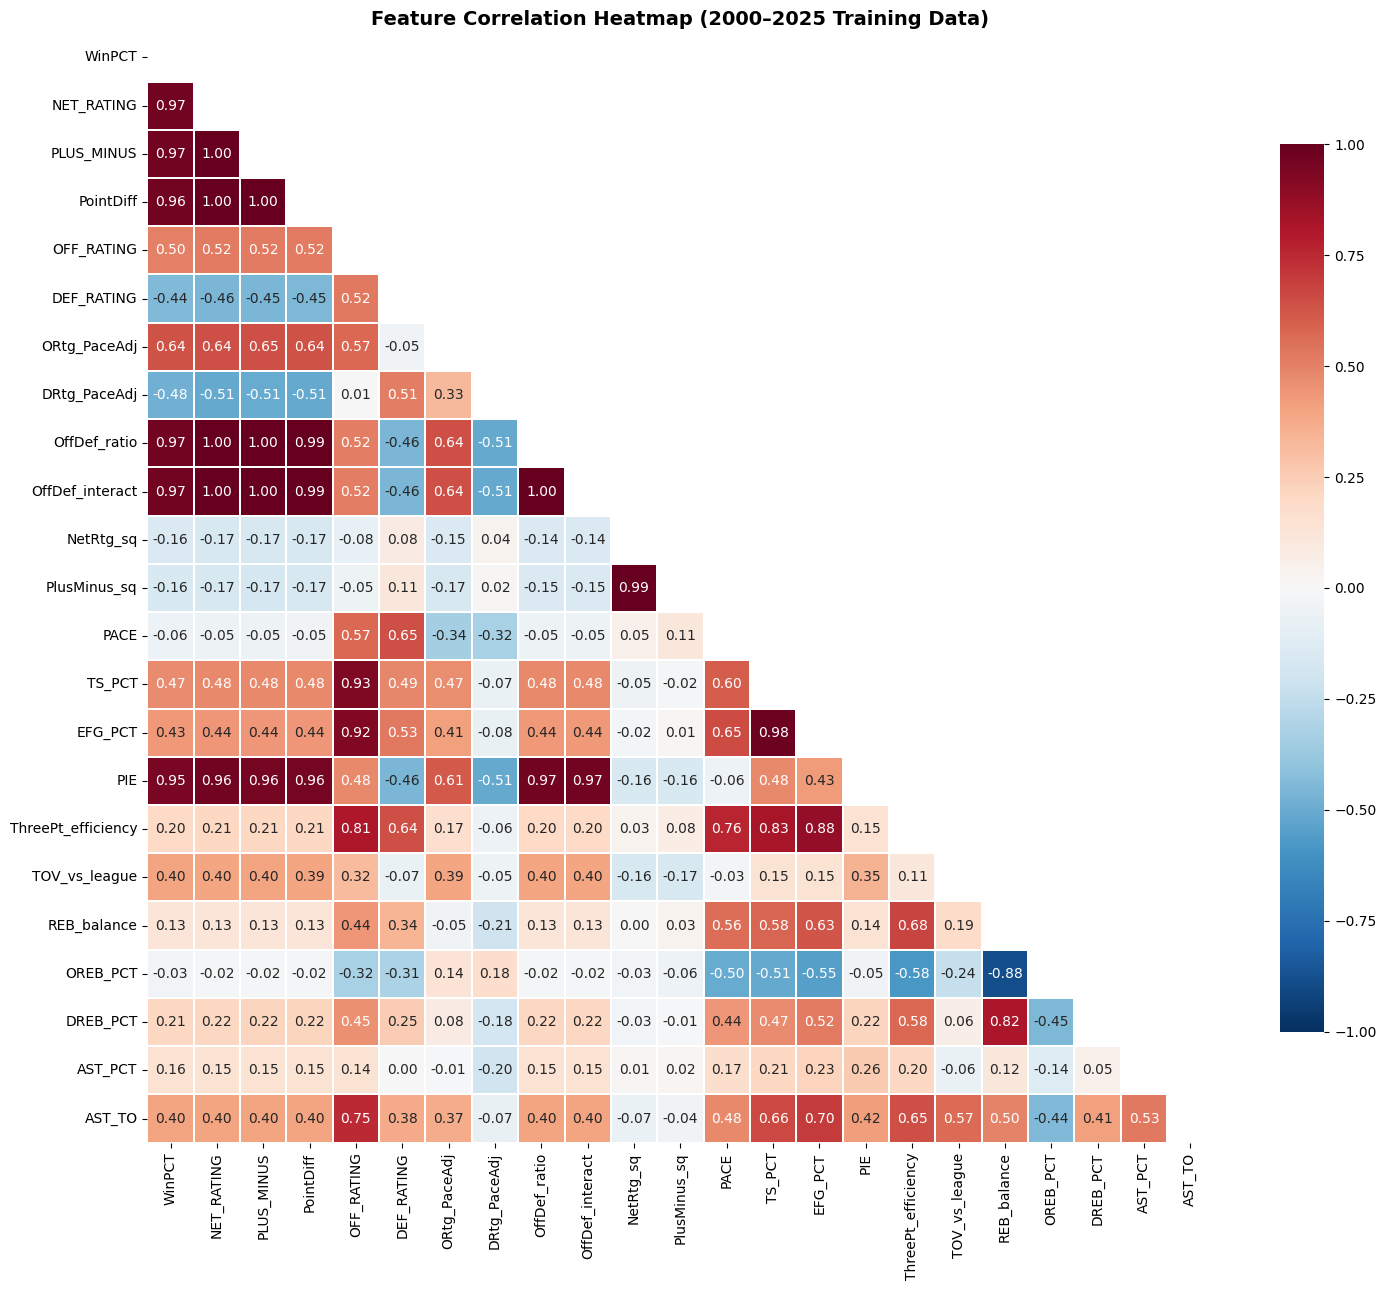

In [9]:
fig, ax = plt.subplots(figsize=(15, 13))
corr = df_train[available].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", linewidths=0.3,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Feature Correlation Heatmap (2000–2025 Training Data)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. LASSO Logistic Regression

Trained on 25 seasons (2000-2025) of regular season team stats.  
Predicts the probability that a team wins the championship given their regular season performance.

- LASSO (L1) penalty enforces sparsity - irrelevant features shrink to exactly 0  
- `LogisticRegressionCV` selects optimal regularization `C` via 5-fold stratified CV  
- `class_weight='balanced'` handles the severe class imbalance (~3.3% positive rate)


In [10]:
def fit_lasso_model(X: np.ndarray, y: np.ndarray) -> Pipeline:
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", LogisticRegressionCV(
            Cs=np.logspace(-4, 2, 60),
            cv=cv,
            penalty="l1",
            solver="saga",
            scoring="neg_log_loss",
            max_iter=5000,
            random_state=42,
            class_weight="balanced",
        ))
    ])
    model.fit(X, y)
    return model

print("Fitting LASSO model on 2000–2025 data...")
model = fit_lasso_model(X_train, y_train)
print("Done.")


Fitting LASSO model on 2000–2025 data...
Done.


## 5. Model Evaluation (In-Sample, 2000-2025)

In [11]:
probs_train = model.predict_proba(X_train)[:, 1]
preds_train = model.predict(X_train)

lasso_step = model.named_steps["lasso"]
coefs      = lasso_step.coef_[0]
best_C     = lasso_step.C_[0]

print("=== Training Performance ===")
print(f"  Accuracy  : {accuracy_score(y_train, preds_train):.4f}")
print(f"  Log-Loss  : {log_loss(y_train, probs_train):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_train, probs_train):.4f}")
print(f"  Best C    : {best_C:.6f}  (lambda = {1/best_C:.4f})")
print(f"  Non-zero  : {np.sum(coefs != 0)}/{len(coefs)} features selected by LASSO")

coef_df = pd.DataFrame({
    "Feature": available, "Coefficient": coefs
}).sort_values("Coefficient", key=abs, ascending=False)

print("\n=== Selected Features ===")
coef_df[coef_df["Coefficient"] != 0]


=== Training Performance ===
  Accuracy  : 0.8839
  Log-Loss  : 0.2814
  ROC-AUC   : 0.9595
  Best C    : 1.477378  (lambda = 0.6769)
  Non-zero  : 15/23 features selected by LASSO

=== Selected Features ===


,Feature,Coefficient
14,EFG_PCT,5.157536
0,WinPCT,3.569555
13,TS_PCT,-3.080762
15,PIE,2.547771
6,ORtg_PaceAdj,-1.474095
12,PACE,-1.348112
19,OREB_PCT,1.032377
3,PointDiff,0.766847
11,PlusMinus_sq,-0.551513
20,DREB_PCT,0.514999


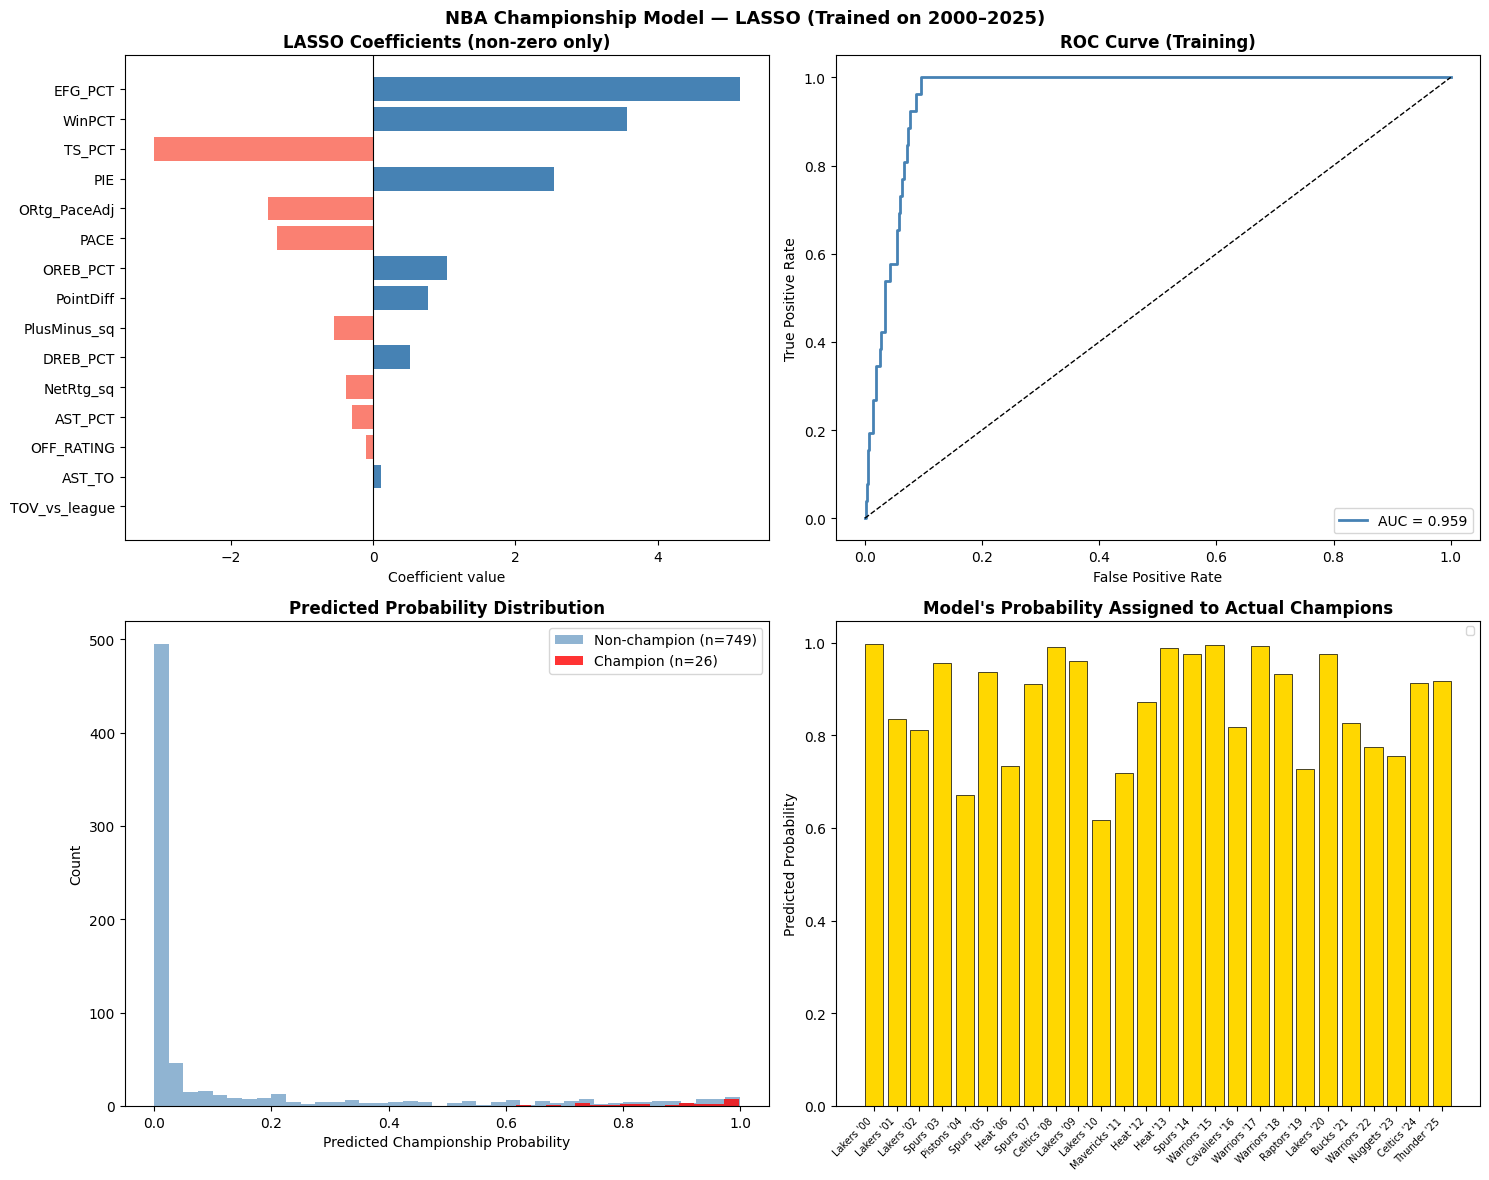

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1: Coefficients
ax = axes[0, 0]
nz = coef_df[coef_df["Coefficient"] != 0]
bar_cols = ["steelblue" if c > 0 else "salmon" for c in nz["Coefficient"]]
ax.barh(nz["Feature"], nz["Coefficient"], color=bar_cols)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("LASSO Coefficients (non-zero only)", fontweight="bold")
ax.set_xlabel("Coefficient value")
ax.invert_yaxis()

# 2: ROC curve
ax = axes[0, 1]
fpr, tpr, _ = roc_curve(y_train, probs_train)
auc = roc_auc_score(y_train, probs_train)
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.3f}")
ax.plot([0,1],[0,1], "k--", lw=1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve (Training)", fontweight="bold"); ax.legend()

# 3: Probability distribution
ax = axes[1, 0]
ax.hist(probs_train[y_train==0], bins=40, alpha=0.6, color="steelblue",
        label=f"Non-champion (n={sum(y_train==0)})")
ax.hist(probs_train[y_train==1], bins=15, alpha=0.8, color="red",
        label=f"Champion (n={sum(y_train==1)})")
ax.set_xlabel("Predicted Championship Probability")
ax.set_ylabel("Count")
ax.set_title("Predicted Probability Distribution", fontweight="bold")
ax.legend()

# 4: Historical champion probabilities
ax = axes[1, 1]
champ_probs = df_train[y_train==1][["season","TEAM_NAME"]].copy()
champ_probs["prob"] = probs_train[y_train==1]
champ_probs = champ_probs.sort_values("season")
champ_probs["label"] = champ_probs["TEAM_NAME"].str.split().str[-1] + " '" + champ_probs["season"].astype(str).str[-2:]
ax.bar(range(len(champ_probs)), champ_probs["prob"], color="gold", edgecolor="black", lw=0.5)
ax.set_xticks(range(len(champ_probs)))
ax.set_xticklabels(champ_probs["label"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Predicted Probability")
ax.set_title("Model's Probability Assigned to Actual Champions", fontweight="bold")
ax.legend(fontsize=8)

plt.suptitle("NBA Championship Model — LASSO (Trained on 2000–2025)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. 2025-26 Championship Predictions

The model is applied to current 2025-26 regular season stats.  
Probabilities are normalized so they sum to 100% across all teams.


In [21]:
# Prepare prediction data — must use same features as training
avail_pred = [c for c in available if c in processed_pred.columns]
df_pred    = processed_pred[avail_pred + ["TEAM_NAME", "season"]].dropna(subset=avail_pred)

# Align feature columns exactly with training (fill missing with 0)
X_pred = df_pred[available].fillna(0).values.astype(float)

# Generate probabilities
df_pred = df_pred.copy()
df_pred["ChampProb"]      = model.predict_proba(X_pred)[:, 1]
df_pred["ChampProb_norm"] = df_pred["ChampProb"] / df_pred["ChampProb"].sum()

# Add useful stats for display
stat_cols = ["TEAM_NAME", "WinPCT", "NET_RATING", "OFF_RATING",
             "DEF_RATING", "TS_PCT", "PIE", "ChampProb", "ChampProb_norm"]
stat_cols = [c for c in stat_cols if c in df_pred.columns]

results = df_pred[stat_cols]            .sort_values("ChampProb_norm", ascending=False)            .reset_index(drop=True)
results.index += 1

print(f"\n=== 2025-26 Championship Probability Rankings ===\n")
display_results = results.copy()
display_results["ChampProb_norm"] = display_results["ChampProb_norm"].map("{:.2%}".format)
display_results["ChampProb"]      = display_results["ChampProb"].map("{:.4f}".format)
display_results



=== 2025-26 Championship Probability Rankings ===



,TEAM_NAME,WinPCT,NET_RATING,OFF_RATING,DEF_RATING,TS_PCT,PIE,ChampProb,ChampProb_norm
1,Detroit Pistons,0.732,8.4,117.3,108.9,0.583,0.552,0.7103,28.11%
2,San Antonio Spurs,0.756,8.3,118.7,110.4,0.595,0.542,0.5458,21.60%
3,Houston Rockets,0.634,5.4,117.5,112.1,0.576,0.533,0.4007,15.86%
4,Oklahoma City Thunder,0.780,11.1,117.6,106.5,0.599,0.562,0.3617,14.31%
5,Boston Celtics,0.683,8.3,120.0,111.7,0.583,0.536,0.2402,9.50%
6,New York Knicks,0.646,6.4,118.7,112.3,0.590,0.533,0.1335,5.28%
7,Cleveland Cavaliers,0.634,4.2,118.3,114.1,0.595,0.522,0.0347,1.37%
8,Denver Nuggets,0.659,5.2,121.2,116.0,0.616,0.529,0.0298,1.18%
9,Los Angeles Lakers,0.646,1.5,117.0,115.5,0.609,0.513,0.0285,1.13%
10,Minnesota Timberwolves,0.598,3.1,115.6,112.5,0.592,0.516,0.0222,0.88%


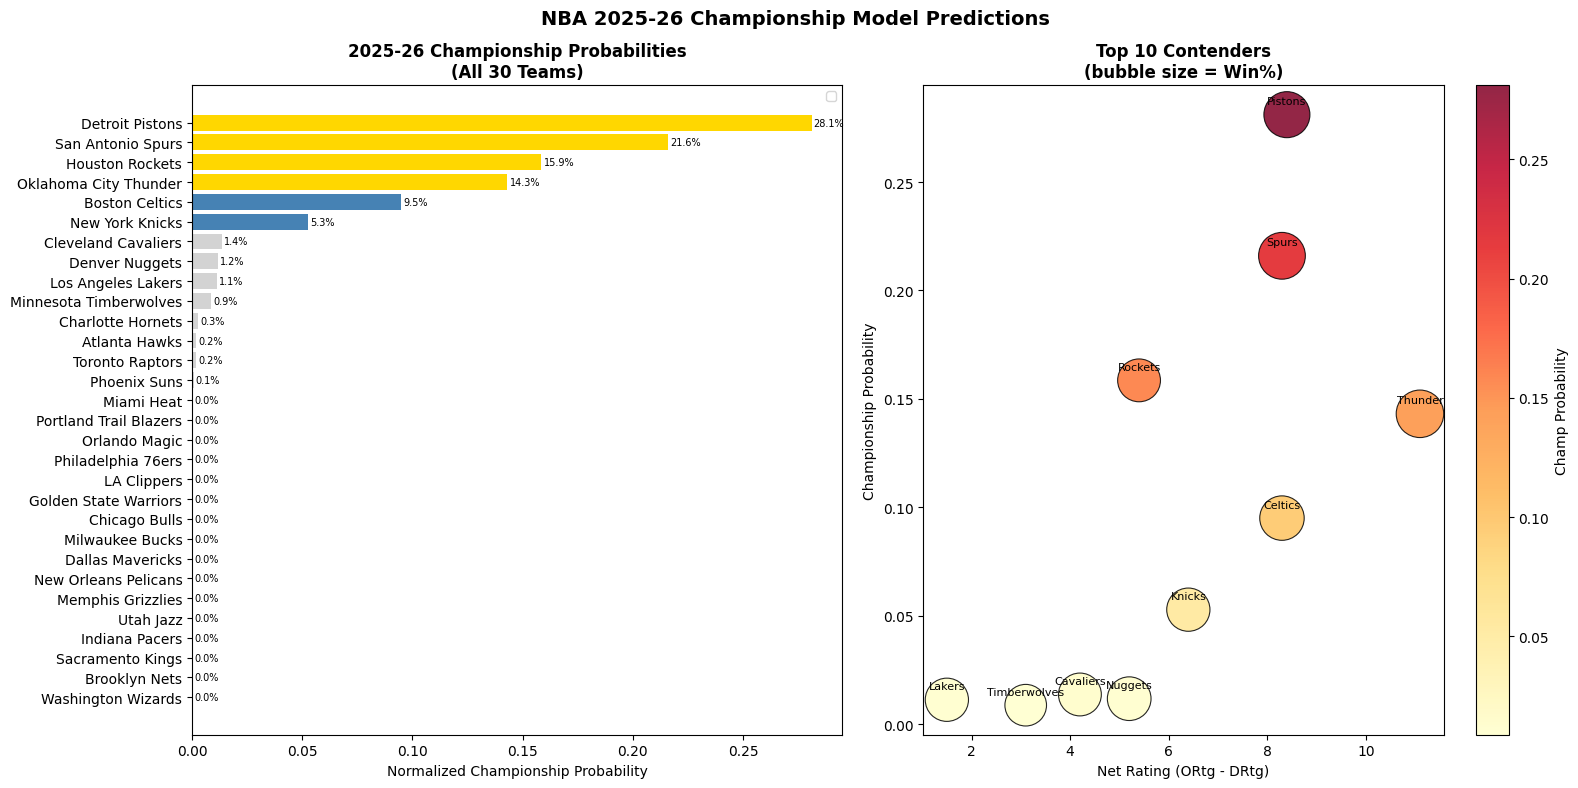

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: full league ranking
ax = axes[0]
results_sorted = results.sort_values("ChampProb_norm", ascending=True)
colors = ["gold"      if p > 0.10 else
          "steelblue" if p > 0.04 else
          "lightgray"
          for p in results_sorted["ChampProb_norm"]]
ax.barh(results_sorted["TEAM_NAME"], results_sorted["ChampProb_norm"], color=colors)
ax.set_xlabel("Normalized Championship Probability")
ax.set_title(f"2025-26 Championship Probabilities\n(All 30 Teams)",
             fontweight="bold")
ax.legend(fontsize=9)
# Add percentage labels
for i, (_, row) in enumerate(results_sorted.iterrows()):
    ax.text(row["ChampProb_norm"] + 0.001, i,
            f"{row['ChampProb_norm']:.1%}", va="center", fontsize=7)

# Right: top 10 with net rating bubble
ax = axes[1]
top10 = results.head(10).copy()
scatter = ax.scatter(top10["NET_RATING"], top10["ChampProb_norm"],
                     s=top10["WinPCT"] * 1500,
                     c=top10["ChampProb_norm"],
                     cmap="YlOrRd", edgecolors="black", lw=0.8, alpha=0.85)
for _, row in top10.iterrows():
    name = row["TEAM_NAME"].split()[-1]  # last word of team name
    ax.annotate(name, (row["NET_RATING"], row["ChampProb_norm"]),
                fontsize=8, ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points")
ax.set_xlabel("Net Rating (ORtg - DRtg)")
ax.set_ylabel("Championship Probability")
ax.set_title("Top 10 Contenders\n(bubble size = Win%)", fontweight="bold")
plt.colorbar(scatter, ax=ax, label="Champ Probability")

plt.suptitle("NBA 2025-26 Championship Model Predictions",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Historical Validation - Did Champions Have the Highest Probability?

Champion was ranked #1 in probability: 9/26 seasons
Champion was ranked top-3: 21/26 seasons
Champion was ranked top-5: 26/26 seasons
Average champion rank: 2.2



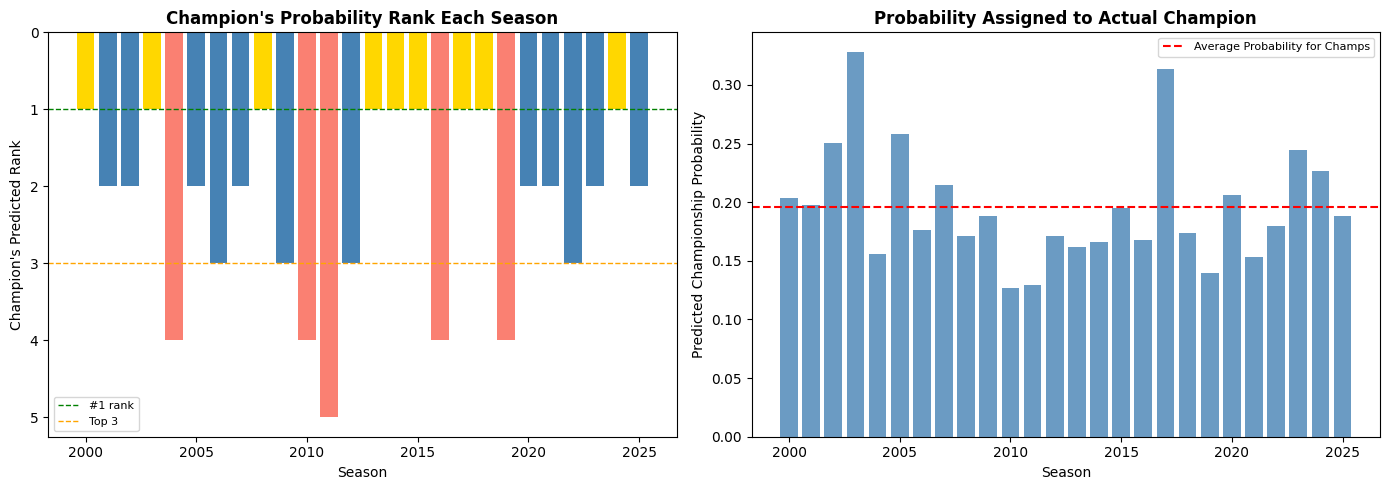

,season,champion,rank,prob
0,2000,Los Angeles Lakers,1,0.203436
1,2001,Los Angeles Lakers,2,0.197839
2,2002,Los Angeles Lakers,2,0.250454
3,2003,San Antonio Spurs,1,0.328374
4,2004,Detroit Pistons,4,0.156079
5,2005,San Antonio Spurs,2,0.258383
6,2006,Miami Heat,3,0.176564
7,2007,San Antonio Spurs,2,0.214581
8,2008,Boston Celtics,1,0.171483
9,2009,Los Angeles Lakers,3,0.188218


In [15]:
# For each season, find the rank of the actual champion by predicted probability
validation = []
for season in TRAIN_SEASONS:
    season_df = df_train[df_train["season"] == season].copy()
    season_df["prob"] = probs_train[df_train["season"] == season]
    # Calculate normalized probability for the current season's data
    season_df["prob_norm"] = season_df["prob"] / season_df["prob"].sum()
    season_df = season_df.sort_values("prob", ascending=False).reset_index(drop=True)
    champ_row = season_df[season_df["champion"] == 1]
    if len(champ_row) > 0:
        rank = champ_row.index[0] + 1
        prob = champ_row.iloc[0]["prob_norm"]
        name = champ_row.iloc[0]["TEAM_NAME"]
        validation.append({"season": season, "champion": name, "rank": rank, "prob": prob})

val_df = pd.DataFrame(validation)
print(f"Champion was ranked #1 in probability: {(val_df['rank']==1).sum()}/{len(val_df)} seasons")
print(f"Champion was ranked top-3: {(val_df['rank']<=3).sum()}/{len(val_df)} seasons")
print(f"Champion was ranked top-5: {(val_df['rank']<=5).sum()}/{len(val_df)} seasons")
print(f"Average champion rank: {val_df['rank'].mean():.1f}")
print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.bar(val_df["season"], val_df["rank"], color=[
    "gold" if r == 1 else "steelblue" if r <= 3 else "salmon"
    for r in val_df["rank"]
])
ax.axhline(1, color="green", lw=1, linestyle="--", label="#1 rank")
ax.axhline(3, color="orange", lw=1, linestyle="--", label="Top 3")
ax.set_xlabel("Season"); ax.set_ylabel("Champion's Predicted Rank")
ax.set_title("Champion's Probability Rank Each Season", fontweight="bold")
ax.legend(fontsize=8)
ax.invert_yaxis()

ax = axes[1]
ax.bar(val_df["season"], val_df["prob"], color="steelblue", alpha=0.8)
ax.axhline(val_df["prob"].mean(), color="red", lw=1.5, linestyle="--", label="Average Probability for Champs")
ax.set_xlabel("Season"); ax.set_ylabel("Predicted Championship Probability")
ax.set_title("Probability Assigned to Actual Champion", fontweight="bold")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()
val_df